In [2]:
import jax
import jax.numpy as jnp
import pennylane as qml
from flax import nnx
from functools import partial
import numpy as np
from QNN_jax import initialize_parameters
import jax
jax.config.update("jax_enable_x64", True)
# -------------------------- 第一步：改造量子电路，原生支持Batch输入 --------------------------
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑：
    - x: 输入张量，形状为 (batch_size, n_qubits)（Batch维度在前）
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    - 所有量子门操作自动沿Batch维度向量化，无需手动循环
    """
    # 1. 强制将输入转为JAX张量（兼容np.array/其他格式），并确保是二维（batch, n_qubits）
    x = jnp.atleast_2d(x)
    # 校验特征维度（Batch维度不校验，由NNX自动兼容）
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 2. 数据编码：向量化RX门（自动兼容Batch）
    # qml.RX支持批量角度输入，会自动为每个Batch样本应用对应角度的门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)  # x[:, i] 取所有Batch样本的第i个特征
    
    # 3. 变分层：向量化旋转/纠缠门（Batch维度自动兼容）
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)  # RX参数
            qml.RZ(params[layer, 2*i+1], wires=i)  # RZ参数
    # 4. 测量：返回每个量子比特的期望值

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [3]:
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
# 封装QNode：interface="jax" 确保兼容JAX/NNX的Batch计算
qnode = qml.QNode(quantum_neural_network, dev, interface="jax")
# 测试单个输入
params = initialize_parameters(n_layers, n_qubits)
result = qnode(x=[1,0,1,0], params=params, n_layers=n_layers, n_qubits=n_qubits)
print("单个输入结果:", result)
result

单个输入结果: [Array([0.21062209], dtype=float64), Array([0.09039875], dtype=float64), Array([-0.27025594], dtype=float64), Array([-0.19796214], dtype=float64)]


[Array([0.21062209], dtype=float64),
 Array([0.09039875], dtype=float64),
 Array([-0.27025594], dtype=float64),
 Array([-0.19796214], dtype=float64)]

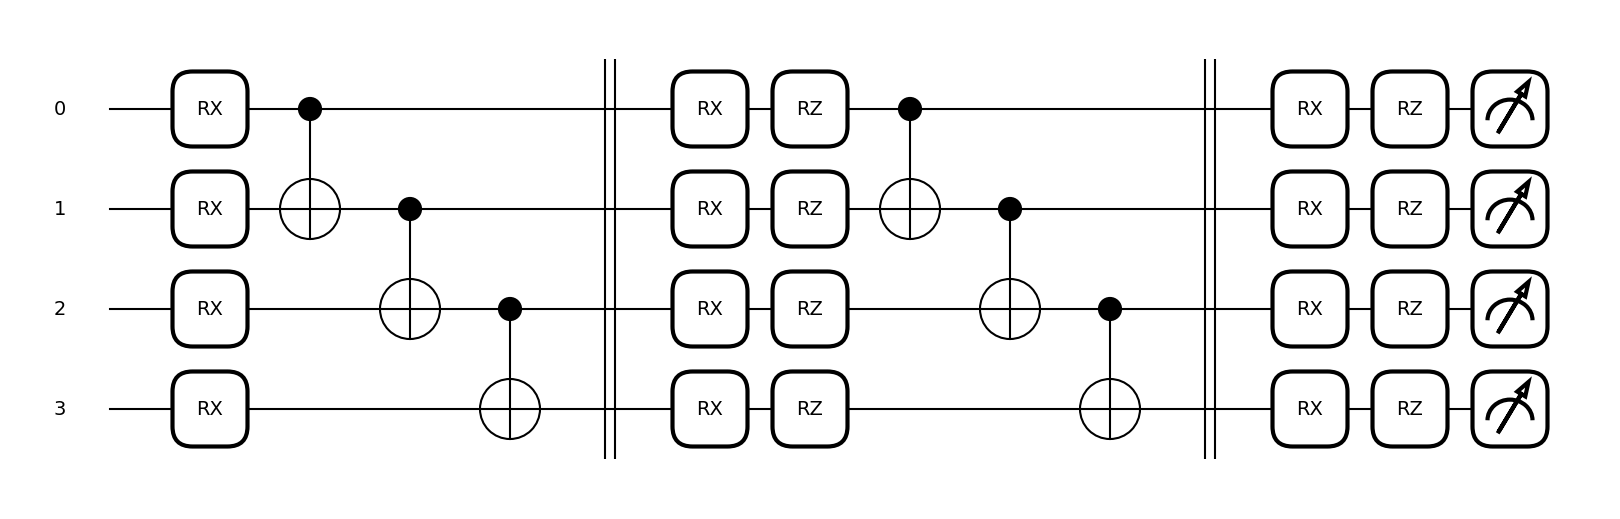

In [4]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

尝试把 QNN jax化

In [5]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [6]:
rngs = nnx.Rngs(params=0)
key = rngs.params()
qnn_func = qnn_circuit(n_qubits=4,n_layers=2)
qnn_func(params=nnx.Param(jax.random.normal(key, (2, 4))),x=[[1,0,1,0]])

[Array([0.3830531], dtype=float64),
 Array([-0.28055583], dtype=float64),
 Array([0.21015436], dtype=float64),
 Array([-0.17590582], dtype=float64)]

In [7]:
linear_layer= nnx.Linear(in_features=4, out_features=4,use_bias=False,rngs=rngs)

In [8]:
y = qnn_func(params=nnx.Param(initialize_parameters(2,4)),x=[1,0,1,0])
y = jnp.array(y)
y

Array([[-0.94512592],
       [ 0.27064636],
       [-0.04444953],
       [-0.11745069]], dtype=float64)

In [9]:
y = qnn_func(params=nnx.Param(initialize_parameters(2,4)), x=[[1,0,1,0]])
y = jnp.array(y)
x = linear_layer(y.reshape(1, 4))
x = nnx.relu(x)
x

Array([[1.48429576, 0.66259167, 0.2952126 , 0.        ]], dtype=float64)

In [10]:
qnn_func(params=nnx.Param(initialize_parameters(2,4)),x=[[1,0,1,0]])


[Array([0.16055171], dtype=float64),
 Array([-0.1898552], dtype=float64),
 Array([-0.05393847], dtype=float64),
 Array([0.05212048], dtype=float64)]

In [11]:
q_fun = qnn_circuit(n_qubits=4,n_layers=2)
qnn_func(x=[[1,0,1,0]],params=nnx.Param(jax.random.normal(key,(2,4),dtype=jnp.float32)))

[Array([-0.09625135], dtype=float64),
 Array([0.37468903], dtype=float64),
 Array([-0.02295585], dtype=float64),
 Array([-0.01601768], dtype=float64)]

In [28]:
from flax import nnx
from functools import partial
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs,n_qubits:int,n_layer:int):
        key = rngs.params()
        # 不存储PRNGKey，直接使用rngs.params()初始化参数
        self.n_qubits,self.n_layer = n_qubits,n_layer
        self.qnn_params = nnx.Param(jax.random.normal(key, (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits,out_features=self.n_qubits,use_bias=False,rngs=rngs, dtype=jnp.float32)
        
    
    def __call__(self, s:np.array):
        # 确保输入是JAX数组
        s = jnp.array(s, dtype=jnp.float32)
        # 获取QNN输出
        qnn_output = self.qnn_layer(x=s,params=self.qnn_params) #dtype=float32
        #print(qnn_output)
        # 将QNN输出转换为float32类型
        #qnn_output = jnp.array(qnn_output, dtype=jnp.float32).reshape(-1,self.n_qubits)
        qnn_output = jnp.stack(qnn_output, axis=1)  # 形状: (batch_size, n_qubits)
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32)
        
        #print(qnn_output.dtype)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
        

In [16]:
model = QNNLinear(n_qubits=4,n_layer=2,rngs=nnx.Rngs(params=0))

接下来在$H_2$分子的VMC中尝试使用这个经典-量子混合模型作为 Ansatz

In [29]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length*1, 0., 0.)),
    ('H', (bond_length*2., 0., 0.)),
    ('H', (bond_length*3, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

Hartree-Fock能量: -2.09789961 Ha
FCI能量: -2.13888991 Ha


In [21]:
import itertools

# 排列组合
letters_alpha= [0,1,2,3]
letters_beta=  [4,5,6,7]
combinations_alpha = itertools.combinations(letters_alpha, 2)
combinations_beta =  itertools.combinations(letters_beta, 2)
clusters = list(combinations_alpha) + list(combinations_beta)
print(clusters)

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [22]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(2, 2)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
#cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=clusters)
# g = nk.graph.Graph(edges=cluster)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [30]:
from flax import nnx
from functools import partial
import jax

model = QNNLinear(rngs=nnx.Rngs(2),n_qubits=8, n_layer=2)


In [24]:
hi.all_states()[0]

Array([0, 0, 1, 1, 0, 0, 1, 1], dtype=int8)

In [26]:
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32


In [27]:
energy_stats = vstate.expect(ha)
print("能量平均值:", energy_stats.mean.real)
print("统计误差:", energy_stats.error_of_mean.real)
print("局域能量方差:", energy_stats.variance.real)

[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32
[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32
[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float6

In [31]:
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vstate, preconditioner=sr)

# 运行优化
exp_name = "h4_molecule_qnn"

In [32]:
gs.run(300, out=exp_name)

  0%|          | 0/300 [00:00<?, ?it/s]

[Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>]
float32
[Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>, Traced<float64[39312]>with<DynamicJaxprTrace>]
float32
[Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<

100%|██████████| 300/300 [33:54<00:00,  6.78s/it, Energy=-2.099202 ± 0.000069 [σ²=0.000005, R̂=1.0079]]   


(JsonLog('h4_molecule_qnn', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.6634221076965332
   	Params: 0.7865164279937744,)

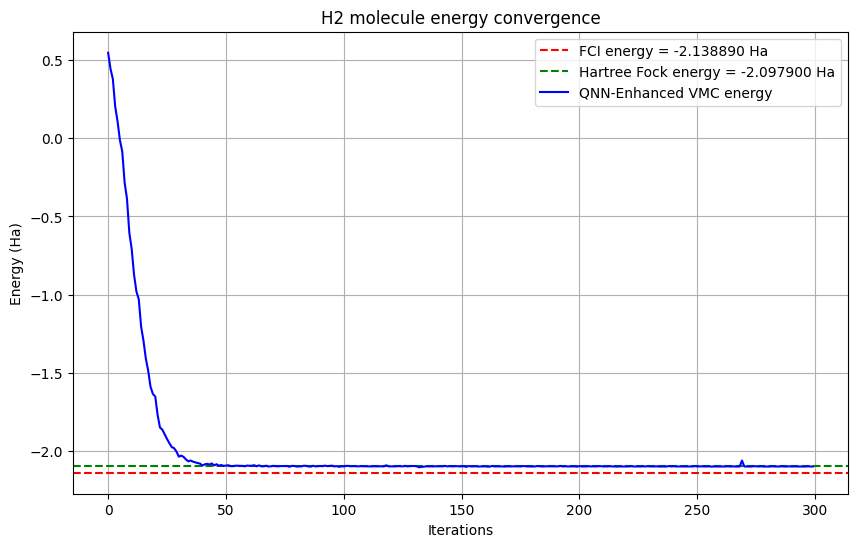


最终VMC能量: -2.09920229 Ha
与FCI能量误差: 0.03968762 Ha


In [35]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="QNN-Enhanced VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")


In [36]:
vstate.expect(ha)

-2.099e+00 ± 1.399e-17 [σ²=1.972e-31, R̂=1.3621]

In [ ]:
# 假设 vs 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vs.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")
